# Metody Inteligencji Obliczeniowej
## Projekt: Predykcja zainteresowania postami w social media z użyciem metod NLP

**Temat:** przewidywanie zainteresowania tweetami Donalda Trumpa mierzonego liczbą retweetów z wykorzystaniem reprezentacji tekstu, modeli regresyjnych oraz interpretacji SHAP.

**Autorzy:** Jan Kot, Krystsina Mironenka, Mikhail Shupliakou

# 1. Imports and configuration

Notebook został uporządkowany tak, aby można go było uruchomić od początku do końca po restarcie kernela. Surowy zbiór danych ma jedno źródło prawdy: `data/raw/trumptweets.csv`. Artefakty przetworzone, modele i metadane podziałów są zapisywane w katalogu `processed/`.

In [1]:
import json
import re
import shutil
import subprocess
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack, save_npz, load_npz
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as exc:
    xgb = None
    XGBOOST_AVAILABLE = False
    print(f"XGBoost is not available: {exc}")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print(f"SHAP is not available: {exc}")

RANDOM_STATE = 42
MIN_DATE = "2015-01-01"
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
RAW_DATA_PATH = RAW_DIR / "trumptweets.csv"
PROCESSED_DIR = Path("processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 2. Dataset loading

Dane są pobierane tylko wtedy, gdy nie istnieje lokalny plik `data/raw/trumptweets.csv`. Jeżeli plik jest już dostępny, notebook korzysta z niego bez ponownego pobierania. Dzięki temu wynik jest odtwarzalny i nie zależy od ręcznego kopiowania danych między sekcjami.

In [2]:
def _find_csv_with_required_columns(directory):
    # Return the first CSV that looks like the Trump tweets dataset.
    required = {"date", "content", "retweets"}
    for csv_path in sorted(Path(directory).rglob("*.csv")):
        try:
            sample = pd.read_csv(csv_path, nrows=5)
        except Exception:
            continue
        lower_cols = {str(c).lower() for c in sample.columns}
        if required.issubset(lower_cols):
            return csv_path
    return None


def download_kaggle_dataset_if_needed():
    # Download or copy the raw dataset only when RAW_DATA_PATH is missing.
    if RAW_DATA_PATH.exists():
        print(f"Raw dataset already exists: {RAW_DATA_PATH}")
        return RAW_DATA_PATH

    local_candidate = _find_csv_with_required_columns(Path.cwd())
    if local_candidate is not None and local_candidate.resolve() != RAW_DATA_PATH.resolve():
        shutil.copy2(local_candidate, RAW_DATA_PATH)
        print(f"Copied local dataset from {local_candidate} to {RAW_DATA_PATH}")
        return RAW_DATA_PATH

    try:
        import kagglehub
        downloaded_dir = Path(kagglehub.dataset_download("austinreese/trump-tweets"))
        downloaded_csv = _find_csv_with_required_columns(downloaded_dir)
        if downloaded_csv is None:
            raise FileNotFoundError("No matching CSV found in kagglehub download.")
        shutil.copy2(downloaded_csv, RAW_DATA_PATH)
        print(f"Downloaded dataset with kagglehub and saved: {RAW_DATA_PATH}")
        return RAW_DATA_PATH
    except Exception as kagglehub_exc:
        print(f"kagglehub download skipped/failed: {kagglehub_exc}")

    try:
        tmp_dir = DATA_DIR / "kaggle_download"
        tmp_dir.mkdir(parents=True, exist_ok=True)
        subprocess.run(["kaggle", "datasets", "download", "-d", "austinreese/trump-tweets", "-p", str(tmp_dir), "--unzip"], check=True)
        downloaded_csv = _find_csv_with_required_columns(tmp_dir)
        if downloaded_csv is None:
            raise FileNotFoundError("No matching CSV found after Kaggle CLI download.")
        shutil.copy2(downloaded_csv, RAW_DATA_PATH)
        print(f"Downloaded dataset with Kaggle CLI and saved: {RAW_DATA_PATH}")
        return RAW_DATA_PATH
    except Exception as kaggle_cli_exc:
        raise FileNotFoundError(
            "Could not locate or download the dataset. Place the CSV at "
            f"{RAW_DATA_PATH} or configure Kaggle credentials."
        ) from kaggle_cli_exc


def load_raw_data():
    # Load the raw CSV from the single canonical raw-data path.
    path = download_kaggle_dataset_if_needed()
    df_raw = pd.read_csv(path)
    df_raw.columns = [str(c).strip().lower() for c in df_raw.columns]
    if "date" not in df_raw.columns or "content" not in df_raw.columns or "retweets" not in df_raw.columns:
        raise ValueError("Dataset must contain at least date, content and retweets columns.")
    df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce", utc=True).dt.tz_localize(None)
    df_raw["retweets"] = pd.to_numeric(df_raw["retweets"], errors="coerce")
    return df_raw


df_raw = load_raw_data()
print(f"Rows: {len(df_raw):,}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Using Colab cache for faster access to the 'trump-tweets' dataset.
Downloaded dataset with kagglehub and saved: data/raw/trumptweets.csv
Rows: 43,352
Columns: ['id', 'link', 'content', 'date', 'retweets', 'favorites', 'mentions', 'hashtags']


,id,link,content,date,retweets,favorites,mentions,hashtags
0,1698308935,https://twitter.com/realDonaldTrump/status/1698308935,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,2009-05-04 13:54:25,510,917,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/1701461182,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,2009-05-04 20:00:10,34,267,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/1737479987,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,2009-05-08 08:38:08,13,19,NaN,NaN
3,1741160716,https://twitter.com/realDonaldTrump/status/1741160716,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,2009-05-08 15:40:15,11,26,NaN,NaN
4,1773561338,https://twitter.com/realDonaldTrump/status/1773561338,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump",2009-05-12 09:07:28,1375,1945,NaN,NaN


# 3. EDA

Zmienna objaśniana, liczba retweetów, ma silnie skośny rozkład. Dlatego modele są trenowane na `log1p(retweets)`, ale wyniki raportujemy również po powrocie do oryginalnej skali. Ważna jest także zmiana rozkładu w czasie: stare tweety pochodzą z innego okresu Twittera i z innego etapu popularności konta, więc późniejszy test chronologiczny może być dużo trudniejszy.

In [3]:
def basic_eda_frame(df):
    eda = df.dropna(subset=["date", "content", "retweets"]).copy()
    eda = eda[eda["retweets"] >= 0].copy()
    eda["year"] = eda["date"].dt.year
    eda["log_retweets"] = np.log1p(eda["retweets"])
    return eda


df_eda = basic_eda_frame(df_raw)
print(f"Rows after basic validity filtering: {len(df_eda):,}")
print(f"Date range: {df_eda['date'].min()} -> {df_eda['date'].max()}")
print(df_eda["retweets"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

Rows after basic validity filtering: 43,352
Date range: 2009-05-04 13:54:25 -> 2020-06-17 21:28:52
count     43352.000000
mean       6264.766908
std       11120.363335
min           0.000000
50%         396.500000
75%       10753.000000
90%       19914.600000
95%       26012.250000
99%       43948.280000
max      302269.000000
Name: retweets, dtype: float64


In [4]:
yearly_stats = (
    df_eda.groupby("year")
    .agg(
        tweets=("retweets", "size"),
        median_retweets=("retweets", "median"),
        mean_retweets=("retweets", "mean"),
        p90_retweets=("retweets", lambda s: s.quantile(0.90)),
        max_retweets=("retweets", "max"),
    )
    .reset_index()
)
yearly_stats

,year,tweets,median_retweets,mean_retweets,p90_retweets,max_retweets
0,2009,56,22.5,70.357143,90.0,1375
1,2010,143,29.0,184.622378,92.8,8772
2,2011,869,92.0,284.880322,445.6,38607
3,2012,4193,104.0,523.668495,712.6,138576
4,2013,8203,23.0,331.821773,441.8,216536
5,2014,6001,27.0,315.182970,407.0,242667
6,2015,7707,169.0,587.014532,1465.0,74054
7,2016,3945,4593.0,6502.302915,12808.6,289872
8,2017,2231,13959.0,16275.210220,26823.0,302269
9,2018,3001,16553.0,18117.667444,27470.0,158311


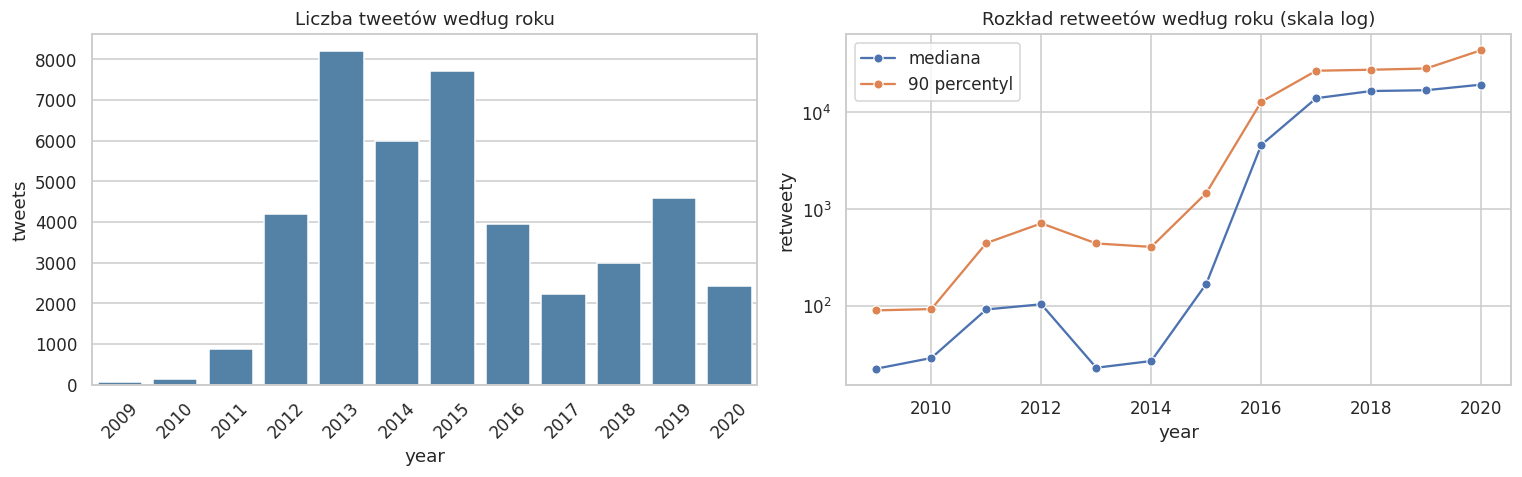

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=yearly_stats, x="year", y="tweets", color="steelblue", ax=axes[0])
axes[0].set_title("Liczba tweetów według roku")
axes[0].tick_params(axis="x", rotation=45)
sns.lineplot(data=yearly_stats, x="year", y="median_retweets", marker="o", label="mediana", ax=axes[1])
sns.lineplot(data=yearly_stats, x="year", y="p90_retweets", marker="o", label="90 percentyl", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Rozkład retweetów według roku (skala log)")
axes[1].set_ylabel("retweety")
plt.tight_layout()
plt.show()

Filtrowanie od `2015-01-01` nie usuwa danych po cichu, tylko tworzy drugi wariant eksperymentu. Wariant „wszystkie lata” pokazuje pełną historię, natomiast wariant „2015+” ogranicza silny przesuw czasowy wynikający z bardzo wczesnego okresu konta i innego rozkładu retweetów.

# 4. Preprocessing and feature engineering

Tekst jest czyszczony prostymi regułami i reprezentowany przez TF-IDF. Metadane obejmują cechy długości tekstu, obecność linków, hashtagów i wzmianek, cechy kalendarzowe oraz opcjonalnie `days_since_first`. Ta ostatnia cecha jest silnym sygnałem czasu, dlatego porównujemy wariant z cechami czasu i bez nich.

In [6]:
EXTRA_STOP_WORDS = {"amp", "rt", "via", "https", "http", "co", "t"}
STOP_WORDS = sorted(set(ENGLISH_STOP_WORDS).union(EXTRA_STOP_WORDS))


def clean_text(text):
    # Clean tweet text for a compact TF-IDF representation.
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def count_list_like(value):
    # Count simple list-like strings from Kaggle columns such as hashtags or mentions.
    if pd.isna(value):
        return 0
    value = str(value).strip()
    if value in {"", "[]", "nan", "None"}:
        return 0
    return max(1, len(re.findall(r"[A-Za-z0-9_]+", value)))


def optional_column(df, name):
    # Return an existing column or an empty object series with the correct index.
    if name in df.columns:
        return df[name]
    return pd.Series(index=df.index, dtype=object)


def prepare_dataframe(df, min_date=None):
    # Prepare a modeling dataframe and optionally filter by minimum date.
    work = df.copy()
    work = work.dropna(subset=["date", "content", "retweets"])
    work = work[work["retweets"] >= 0].copy()
    if min_date is not None:
        work = work[work["date"] >= pd.Timestamp(min_date)].copy()

    work = work.sort_values("date").reset_index(drop=True)
    work["clean_content"] = work["content"].map(clean_text)
    work = work[work["clean_content"].str.len() > 0].reset_index(drop=True)

    work["target_log_retweets"] = np.log1p(work["retweets"].astype(float))
    work["content_length"] = work["content"].astype(str).str.len()
    work["content_words"] = work["content"].astype(str).str.split().str.len()
    work["has_url"] = work["content"].astype(str).str.contains(r"https?://|www\.", regex=True, na=False).astype(int)
    work["has_hashtag"] = work["content"].astype(str).str.contains(r"#\w+", regex=True, na=False).astype(int)
    work["has_mention"] = work["content"].astype(str).str.contains(r"@\w+", regex=True, na=False).astype(int)
    work["num_hashtags"] = optional_column(work, "hashtags").map(count_list_like)
    work["num_mentions"] = optional_column(work, "mentions").map(count_list_like)
    work["hour"] = work["date"].dt.hour
    work["dayofweek"] = work["date"].dt.dayofweek
    work["month"] = work["date"].dt.month
    work["year"] = work["date"].dt.year
    work["days_since_first"] = (work["date"] - work["date"].min()).dt.days
    return work


BASE_METADATA_COLS = ["content_length", "content_words", "has_url", "has_hashtag", "has_mention", "num_hashtags", "num_mentions", "hour", "dayofweek", "month"]
TIME_METADATA_COLS = ["year", "days_since_first"]
META_COLUMNS_WITH_TIME = BASE_METADATA_COLS + TIME_METADATA_COLS
META_COLUMNS_NO_TIME = BASE_METADATA_COLS

# 5. Time-aware split

Podział jest chronologiczny: pierwsze 70% obserwacji trafia do treningu, kolejne 15% do walidacji, a ostatnie 15% do testu. Taki schemat lepiej symuluje realistyczną sytuację przewidywania przyszłych tweetów niż losowy podział.

In [7]:
def chronological_split(df, train_frac=0.70, val_frac=0.15):
    # Split an already sorted dataframe into train, validation and test periods.
    ordered = df.sort_values("date").reset_index(drop=True)
    n = len(ordered)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    if train_end == 0 or val_end <= train_end or val_end >= n:
        raise ValueError("Dataset is too small for the configured chronological split.")
    train_df = ordered.iloc[:train_end].reset_index(drop=True)
    val_df = ordered.iloc[train_end:val_end].reset_index(drop=True)
    test_df = ordered.iloc[val_end:].reset_index(drop=True)
    return train_df, val_df, test_df


def split_date_range(split_df):
    # Return a compact date range string for a split.
    return f"{split_df['date'].min().date()} - {split_df['date'].max().date()}"

# 6. Vectorization without leakage

TF-IDF i skalowanie metadanych są dopasowywane wyłącznie na zbiorze treningowym. Walidacja i test są tylko transformowane przy użyciu obiektów nauczonych na treningu. To eliminuje wyciek informacji z przyszłych okresów do procesu uczenia.

In [8]:
def fit_transform_features(train_df, val_df, test_df, use_text=True, use_metadata=True, use_time_features=True):
    # Fit preprocessing on train only and transform all splits.
    parts_train, parts_val, parts_test = [], [], []
    vectorizer = None
    scaler = None
    feature_names = []
    metadata_cols = META_COLUMNS_WITH_TIME if use_time_features else META_COLUMNS_NO_TIME

    if use_text:
        vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.80, sublinear_tf=True, stop_words=STOP_WORDS)
        X_train_text = vectorizer.fit_transform(train_df["clean_content"])
        X_val_text = vectorizer.transform(val_df["clean_content"])
        X_test_text = vectorizer.transform(test_df["clean_content"])
        parts_train.append(X_train_text)
        parts_val.append(X_val_text)
        parts_test.append(X_test_text)
        feature_names.extend(vectorizer.get_feature_names_out().tolist())

    if use_metadata:
        scaler = StandardScaler()
        X_train_meta = scaler.fit_transform(train_df[metadata_cols])
        X_val_meta = scaler.transform(val_df[metadata_cols])
        X_test_meta = scaler.transform(test_df[metadata_cols])
        parts_train.append(csr_matrix(X_train_meta))
        parts_val.append(csr_matrix(X_val_meta))
        parts_test.append(csr_matrix(X_test_meta))
        feature_names.extend(metadata_cols)

    if not parts_train:
        raise ValueError("At least one feature group must be enabled.")

    X_train = hstack(parts_train).tocsr() if len(parts_train) > 1 else parts_train[0].tocsr()
    X_val = hstack(parts_val).tocsr() if len(parts_val) > 1 else parts_val[0].tocsr()
    X_test = hstack(parts_test).tocsr() if len(parts_test) > 1 else parts_test[0].tocsr()
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": train_df["target_log_retweets"].to_numpy(),
        "y_val": val_df["target_log_retweets"].to_numpy(),
        "y_test": test_df["target_log_retweets"].to_numpy(),
        "vectorizer": vectorizer,
        "scaler": scaler,
        "feature_names": feature_names,
        "metadata_cols": metadata_cols,
    }

# 7. Model training

Porównujemy prosty model bazowy `DummyRegressor`, model tekstowy Ridge na TF-IDF oraz modele łączące tekst z metadanymi. Ridge jest naturalnym punktem odniesienia dla rzadkich macierzy TF-IDF. XGBoost jest używany tylko wtedy, gdy biblioteka jest dostępna w środowisku.

In [9]:
def safe_rmse(y_true, y_pred):
    # Compute RMSE with compatibility across sklearn versions.
    return mean_squared_error(y_true, y_pred) ** 0.5


def evaluate_predictions(y_true_log, y_pred_log):
    # Evaluate predictions on log scale and original retweet scale.
    y_pred_log = np.maximum(np.asarray(y_pred_log), 0)
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return {
        "RMSE log": safe_rmse(y_true_log, y_pred_log),
        "MAE log": mean_absolute_error(y_true_log, y_pred_log),
        "R2 log": r2_score(y_true_log, y_pred_log),
        "MAE original scale": mean_absolute_error(y_true_orig, y_pred_orig),
        "R2 original scale": r2_score(y_true_orig, y_pred_orig),
    }


def train_xgboost_model(X_train, y_train, X_val, y_val):
    # Train a compact XGBoost model, using early stopping when supported.
    if not XGBOOST_AVAILABLE:
        return None
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    try:
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False, early_stopping_rounds=30)
    except TypeError:
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model


def train_and_evaluate_models(features, include_xgboost=True):
    # Train models and return fitted estimators plus validation/test metrics.
    X_train, X_val, X_test = features["X_train"], features["X_val"], features["X_test"]
    y_train, y_val, y_test = features["y_train"], features["y_val"], features["y_test"]
    rows = []
    models = {}
    candidates = {"Dummy mean": DummyRegressor(strategy="mean"), "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE)}

    for name, model in candidates.items():
        model.fit(X_train, y_train)
        models[name] = model
        for split_name, X_split, y_split in [("validation", X_val, y_val), ("test", X_test, y_test)]:
            row = {"model": name, "split": split_name}
            row.update(evaluate_predictions(y_split, model.predict(X_split)))
            rows.append(row)

    if include_xgboost and XGBOOST_AVAILABLE:
        xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
        models["XGBoost"] = xgb_model
        for split_name, X_split, y_split in [("validation", X_val, y_val), ("test", X_test, y_test)]:
            row = {"model": "XGBoost", "split": split_name}
            row.update(evaluate_predictions(y_split, xgb_model.predict(X_split)))
            rows.append(row)

    return models, pd.DataFrame(rows)

# 8. Evaluation

Wszystkie modele są oceniane tymi samymi metrykami. Ujemne `R2` nie jest ukrywane: oznacza, że model jest gorszy od prostego przewidywania średniej na danym podziale. W tym zadaniu może się to zdarzyć przez przesunięcie czasowe, zmianę liczby odbiorców konta i pojedyncze viralowe outliery.

In [10]:
def save_experiment_artifacts(artifacts, feature_set, min_date):
    # Save final split matrices, aligned metadata and preprocessing objects.
    features = artifacts["features"]
    train_df, val_df, test_df = artifacts["train_df"], artifacts["val_df"], artifacts["test_df"]
    save_npz(PROCESSED_DIR / "X_train.npz", features["X_train"])
    save_npz(PROCESSED_DIR / "X_val.npz", features["X_val"])
    save_npz(PROCESSED_DIR / "X_test.npz", features["X_test"])
    np.save(PROCESSED_DIR / "y_train.npy", features["y_train"])
    np.save(PROCESSED_DIR / "y_val.npy", features["y_val"])
    np.save(PROCESSED_DIR / "y_test.npy", features["y_test"])

    meta_cols = ["date", "content", "retweets", "target_log_retweets", "clean_content"] + META_COLUMNS_WITH_TIME
    meta_cols = [col for col in meta_cols if col in train_df.columns]
    train_df[meta_cols].reset_index(drop=True).to_csv(PROCESSED_DIR / "df_train_meta.csv", index=False)
    val_df[meta_cols].reset_index(drop=True).to_csv(PROCESSED_DIR / "df_val_meta.csv", index=False)
    test_df[meta_cols].reset_index(drop=True).to_csv(PROCESSED_DIR / "df_test_meta.csv", index=False)

    if features.get("vectorizer") is not None:
        joblib.dump(features["vectorizer"], PROCESSED_DIR / "tfidf_vectorizer.joblib")
    if features.get("scaler") is not None:
        joblib.dump(features["scaler"], PROCESSED_DIR / "metadata_scaler.joblib")
    for model_name, model in artifacts["models"].items():
        safe_name = model_name.lower().replace(" ", "_")
        joblib.dump(model, PROCESSED_DIR / f"{safe_name}_model.joblib")
    with open(PROCESSED_DIR / "feature_names.json", "w", encoding="utf-8") as f:
        json.dump(features["feature_names"], f, ensure_ascii=False, indent=2)
    metadata = {
        "feature_set": feature_set,
        "min_date": min_date,
        "train_date_range": split_date_range(train_df),
        "validation_date_range": split_date_range(val_df),
        "test_date_range": split_date_range(test_df),
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
    }
    with open(PROCESSED_DIR / "final_experiment_metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)


def run_experiment(min_date=None, feature_set="text_meta_time", save_artifacts=False):
    # Run one complete chronological experiment.
    feature_config = {
        "baseline": {"use_text": False, "use_metadata": False, "use_time_features": False},
        "text_only": {"use_text": True, "use_metadata": False, "use_time_features": False},
        "text_meta_no_time": {"use_text": True, "use_metadata": True, "use_time_features": False},
        "text_meta_time": {"use_text": True, "use_metadata": True, "use_time_features": True},
    }
    prepared = prepare_dataframe(df_raw, min_date=min_date)
    train_df, val_df, test_df = chronological_split(prepared)

    if feature_set == "baseline":
        y_train = train_df["target_log_retweets"].to_numpy()
        y_val = val_df["target_log_retweets"].to_numpy()
        y_test = test_df["target_log_retweets"].to_numpy()
        model = DummyRegressor(strategy="mean").fit(np.zeros((len(y_train), 1)), y_train)
        rows = []
        for split_name, y_split in [("validation", y_val), ("test", y_test)]:
            row = {"model": "Dummy mean", "split": split_name}
            row.update(evaluate_predictions(y_split, model.predict(np.zeros((len(y_split), 1)))))
            rows.append(row)
        models = {"Dummy mean": model}
        features = {"feature_names": [], "y_train": y_train, "y_val": y_val, "y_test": y_test}
        metrics = pd.DataFrame(rows)
    else:
        features = fit_transform_features(train_df, val_df, test_df, **feature_config[feature_set])
        models, metrics = train_and_evaluate_models(features)

    variant_name = "2015+" if min_date else "all years"
    metrics.insert(0, "dataset variant", variant_name)
    metrics.insert(1, "feature set", feature_set)
    metrics.insert(2, "train date range", split_date_range(train_df))
    metrics.insert(3, "validation date range", split_date_range(val_df))
    metrics.insert(4, "test date range", split_date_range(test_df))
    metrics.insert(5, "n samples", len(prepared))
    artifacts = {"prepared": prepared, "train_df": train_df, "val_df": val_df, "test_df": test_df, "features": features, "models": models, "metrics": metrics}
    if save_artifacts and feature_set != "baseline":
        save_experiment_artifacts(artifacts, feature_set=feature_set, min_date=min_date)
    return artifacts

# 9. Time-shift experiment: all years vs 2015+

Poniższa sekcja uruchamia porównywalne eksperymenty dla pełnego zakresu danych i dla tweetów od 2015 roku. W obu przypadkach zachowany jest ten sam podział chronologiczny oraz ta sama procedura dopasowania TF-IDF i skalera tylko na treningu.

In [11]:
experiment_specs = [
    (None, "baseline"),
    (None, "text_only"),
    (None, "text_meta_no_time"),
    (None, "text_meta_time"),
    (MIN_DATE, "baseline"),
    (MIN_DATE, "text_only"),
    (MIN_DATE, "text_meta_no_time"),
    (MIN_DATE, "text_meta_time"),
]
all_artifacts = {}
all_metrics = []
for min_date, feature_set in experiment_specs:
    key = ("2015+" if min_date else "all years", feature_set)
    print(f"Running: {key}")
    artifacts = run_experiment(min_date=min_date, feature_set=feature_set, save_artifacts=False)
    all_artifacts[key] = artifacts
    all_metrics.append(artifacts["metrics"])

comparison_results = pd.concat(all_metrics, ignore_index=True)
comparison_results.sort_values(["split", "RMSE log"]).reset_index(drop=True)

Running: ('all years', 'baseline')
Running: ('all years', 'text_only')
Running: ('all years', 'text_meta_no_time')
Running: ('all years', 'text_meta_time')
Running: ('2015+', 'baseline')
Running: ('2015+', 'text_only')
Running: ('2015+', 'text_meta_no_time')
Running: ('2015+', 'text_meta_time')


,dataset variant,feature set,train date range,validation date range,test date range,n samples,model,split,RMSE log,MAE log,R2 log,MAE original scale,R2 original scale
0,2015+,text_meta_time,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,XGBoost,test,0.596603,0.438690,-0.033553,9448.991297,-0.114326
1,all years,text_meta_time,2009-05-04 - 2016-09-26,2016-09-26 - 2019-02-24,2019-02-24 - 2020-06-17,43259,XGBoost,test,1.263621,1.153160,-4.762076,14493.181218,-1.087392
2,all years,text_meta_time,2009-05-04 - 2016-09-26,2016-09-26 - 2019-02-24,2019-02-24 - 2020-06-17,43259,Ridge,test,1.329826,1.062468,-5.381684,33022.186112,-20.278946
3,2015+,text_only,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,XGBoost,test,1.599344,1.406204,-6.427560,16553.802432,-1.084010
4,2015+,text_meta_no_time,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,XGBoost,test,1.610203,1.255172,-6.528766,14277.854853,-0.760904
5,2015+,text_only,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,Ridge,test,1.731257,1.414006,-7.703332,16455.874821,-1.144968
6,2015+,text_meta_no_time,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,Ridge,test,1.799258,1.476112,-8.400467,17454.865919,-1.544874
7,2015+,text_meta_time,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,Ridge,test,2.642887,2.545222,-19.282422,259912.747948,-400.585167
8,2015+,baseline,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,Dummy mean,test,2.709653,2.649368,-20.320133,20789.001977,-1.731435
9,2015+,text_only,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,Dummy mean,test,2.709653,2.649368,-20.320133,20789.001977,-1.731435


In [23]:
comparison_table = comparison_results.pivot_table(
    index=["dataset variant", "feature set", "model", "train date range", "validation date range", "test date range", "n samples"],
    columns="split",
    values=["RMSE log", "MAE log", "R2 log", "MAE original scale", "R2 original scale"],
)
comparison_table

MAE log  \
split                                                                                                                               test   
dataset variant feature set       model      train date range        validation date range   test date range         n samples             
2015+           baseline          Dummy mean 2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      2.649368   
                text_meta_no_time Dummy mean 2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      2.649368   
                                  Ridge      2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      1.476112   
                                  XGBoost    2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      1.255172   
                text_meta_time    Dummy mean 2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      2.649368   
                                  Ridge      2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      2.545222   
                                  XGBoost    2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      0.438690   
                text_only         Dummy mean 2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      2.649368   
                                  Ridge      2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      1.414006   
                                  XGBoost    2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796      1.406204   
all years       baseline          Dummy mean 2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      5.204948   
                text_meta_no_time Dummy mean 2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      5.204948   
                                  Ridge      2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      3.069413   
                                  XGBoost    2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      3.776752   
                text_meta_time    Dummy mean 2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      5.204948   
                                  Ridge      2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      1.062468   
                                  XGBoost    2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      1.153160   
                text_only         Dummy mean 2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      5.204948   
                                  Ridge      2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      3.703455   
                                  XGBoost    2009-05-04 - 2016-09-26 2016-09-26 - 2019-02-24 2019-02-24 - 2020-06-17 43259      4.277351   

                                                                                                                                           \
split                                                                                                                          validation   
dataset variant feature set       model      train date range        validation date range   test date range         n samples              
2015+           baseline          Dummy mean 2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796       2.572583   
                text_meta_no_time Dummy mean 2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796       2.572583   
                                  Ridge      2015-01-01 - 2018-12-07 2018-12-07 - 2019-10-10 2019-10-10 - 2020-06-17 23796       1.070643   
                                  XGBoost    2015-01-01 - 2018

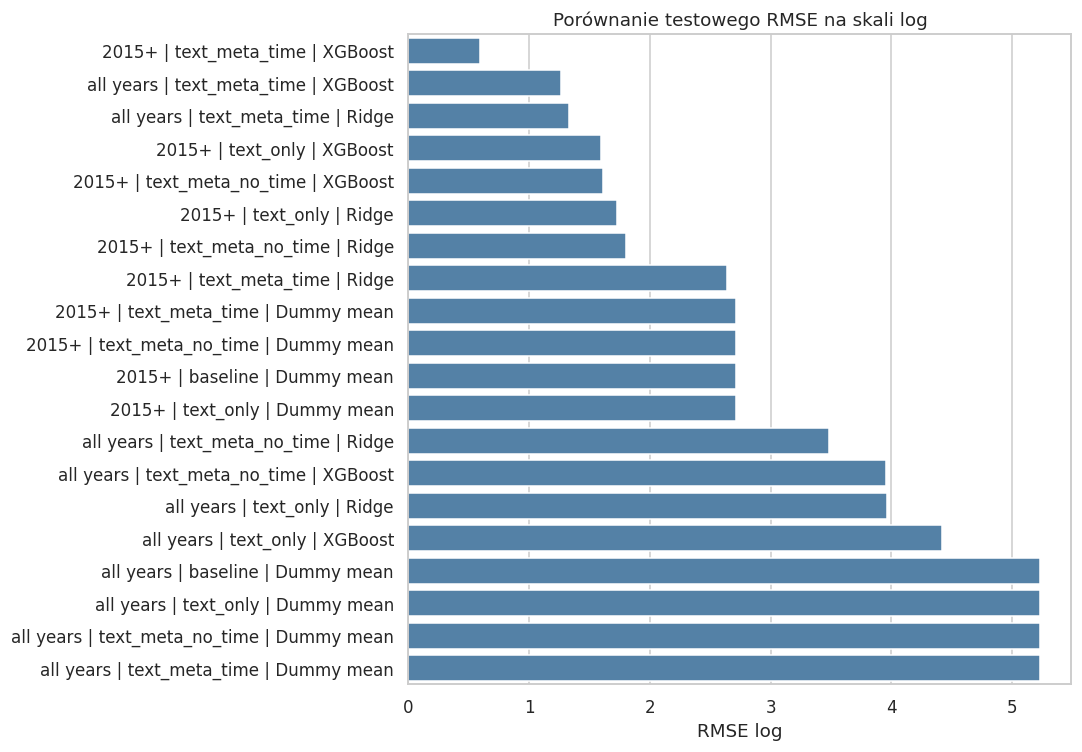

In [13]:
plot_df = comparison_results[comparison_results["split"].eq("test")].copy()
plot_df["experiment"] = plot_df["dataset variant"] + " | " + plot_df["feature set"] + " | " + plot_df["model"]
plot_df = plot_df.sort_values("RMSE log")
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
sns.barplot(data=plot_df, y="experiment", x="RMSE log", color="steelblue", ax=ax)
ax.set_title("Porównanie testowego RMSE na skali log")
ax.set_xlabel("RMSE log")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 10. Final model selection

Model końcowy wybieramy na podstawie walidacji, kontrolując jednocześnie zachowanie na teście. Jeżeli metadane czasowe znacząco poprawiają wynik, traktujemy to jako informację o silnym efekcie temporalnym, a nie dowód, że sam tekst wystarcza do dokładnego przewidywania retweetów.

In [14]:
valid_candidates = comparison_results[(comparison_results["split"] == "validation") & (comparison_results["feature set"] != "baseline") & (comparison_results["model"] != "Dummy mean")].copy()
valid_candidates = valid_candidates.sort_values(["RMSE log", "MAE log"]).reset_index(drop=True)
best_row = valid_candidates.iloc[0]
final_variant = best_row["dataset variant"]
final_min_date = MIN_DATE if final_variant == "2015+" else None
final_feature_set = best_row["feature set"]
final_model_name = best_row["model"]
print("Selected final configuration:")
print(f"  dataset variant: {final_variant}")
print(f"  feature set: {final_feature_set}")
print(f"  model: {final_model_name}")

final_artifacts = run_experiment(min_date=final_min_date, feature_set=final_feature_set, save_artifacts=True)
final_model = final_artifacts["models"][final_model_name]
joblib.dump(final_model, PROCESSED_DIR / "final_model.joblib")
final_metrics = final_artifacts["metrics"]
comparison_results.to_csv(PROCESSED_DIR / "model_comparison_metrics.csv", index=False)
final_metrics.to_csv(PROCESSED_DIR / "final_model_metrics.csv", index=False)
final_metrics[final_metrics["model"].eq(final_model_name)]

Selected final configuration:
  dataset variant: 2015+
  feature set: text_meta_time
  model: XGBoost


,dataset variant,feature set,train date range,validation date range,test date range,n samples,model,split,RMSE log,MAE log,R2 log,MAE original scale,R2 original scale
4,2015+,text_meta_time,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,XGBoost,validation,0.408127,0.303507,0.107867,5725.411031,0.007739
5,2015+,text_meta_time,2015-01-01 - 2018-12-07,2018-12-07 - 2019-10-10,2019-10-10 - 2020-06-17,23796,XGBoost,test,0.596603,0.438690,-0.033553,9448.991297,-0.114326


Wyniki należy interpretować ostrożnie. Niska lub ujemna wartość `R2` oznacza, że model nie potrafi stabilnie przewidywać przyszłych retweetów lepiej niż prosta średnia na danym podziale. W takim przypadku sukces projektu polega przede wszystkim na zbudowaniu poprawnego, niewyciekającego pipeline'u NLP i analizie czynników wpływających na predykcje, a nie na uzyskaniu idealnej dokładności.

# 11. SHAP analysis

SHAP jest liczony na próbie wierszy ze zbioru testowego. Indeksy przykładów odnoszą się do `X_test`, a opis tweeta, data i liczba retweetów są pobierane z `df_test_meta.csv`, którego indeks został zresetowany przy zapisie. Dzięki temu waterfall plot pokazuje predykcję i metadane dokładnie tego samego tweeta.

In [15]:
X_test = load_npz(PROCESSED_DIR / "X_test.npz")
y_test = np.load(PROCESSED_DIR / "y_test.npy")
df_test_meta = pd.read_csv(PROCESSED_DIR / "df_test_meta.csv", parse_dates=["date"])
with open(PROCESSED_DIR / "feature_names.json", encoding="utf-8") as f:
    feature_names = json.load(f)
final_model = joblib.load(PROCESSED_DIR / "final_model.joblib")
assert len(df_test_meta) == X_test.shape[0] == len(y_test), "Test metadata must align with X_test and y_test."
print(f"Aligned test rows: {X_test.shape[0]:,}")

Aligned test rows: 3,570


In [16]:
if not SHAP_AVAILABLE:
    raise ImportError("Install shap to run the SHAP section.")

n_shap = min(500, X_test.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
shap_indices = np.sort(rng.choice(X_test.shape[0], size=n_shap, replace=False))
X_shap = X_test[shap_indices].toarray()

if final_model_name == "XGBoost":
    explainer = shap.TreeExplainer(final_model)
    shap_values_raw = explainer.shap_values(X_shap)
    base_value = explainer.expected_value
else:
    background = X_test[: min(1000, X_test.shape[0])].toarray()
    explainer = shap.LinearExplainer(final_model, background)
    shap_values_raw = explainer.shap_values(X_shap)
    base_value = explainer.expected_value

shap_values = np.asarray(shap_values_raw)
if np.ndim(base_value) > 0:
    base_value = float(np.ravel(base_value)[0])
print(f"SHAP sample shape: {shap_values.shape}")

SHAP sample shape: (500, 5012)


## 11.1 Summary plot

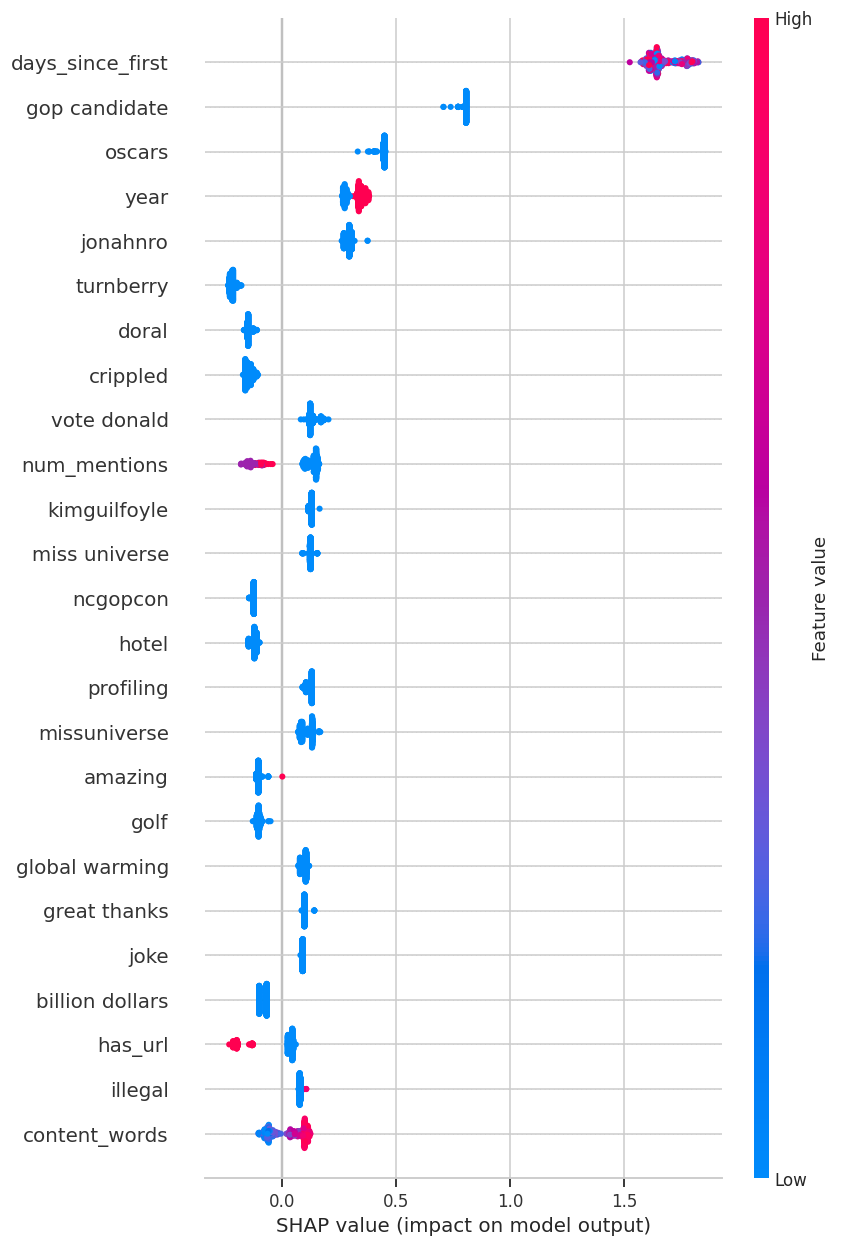

<Figure size 704x528 with 0 Axes>

In [17]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=25, show=True)
plt.tight_layout()
plt.show()

## 11.2 Bar plot

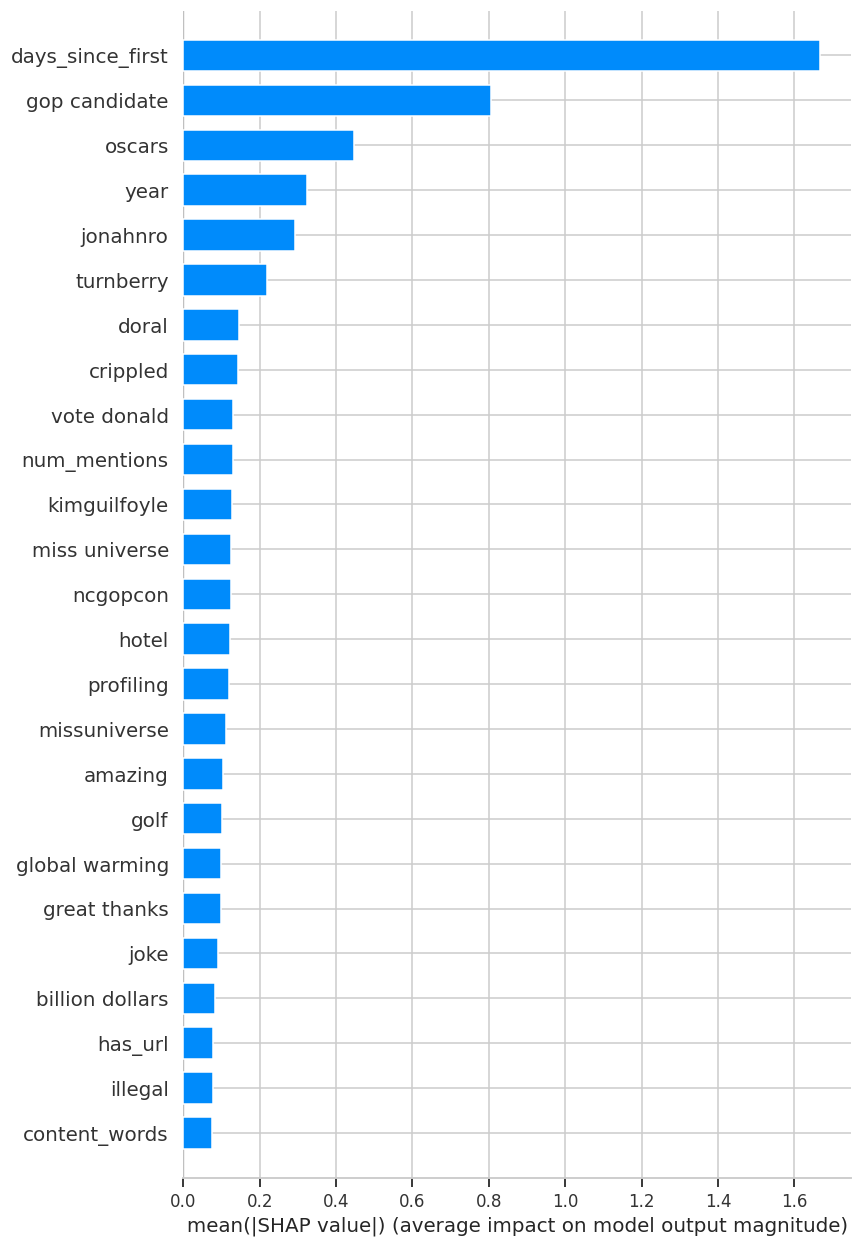

<Figure size 704x528 with 0 Axes>

In [18]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", max_display=25, show=True)
plt.tight_layout()
plt.show()

## 11.3 Najważniejsze cechy SHAP

In [19]:
mean_shap = shap_values.mean(axis=0)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_impact = pd.DataFrame({"feature": feature_names, "mean_shap": mean_shap, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_impact.head(25)

,feature,mean_shap,mean_abs_shap
0,days_since_first,1.666027,1.666027
1,gop candidate,0.805674,0.805674
2,oscars,0.445917,0.445917
3,year,0.325001,0.325001
4,jonahnro,0.291464,0.291464
5,turnberry,-0.219883,0.219883
6,doral,-0.146834,0.146834
7,crippled,-0.144149,0.144149
8,vote donald,0.131461,0.131461
9,num_mentions,0.064146,0.130991


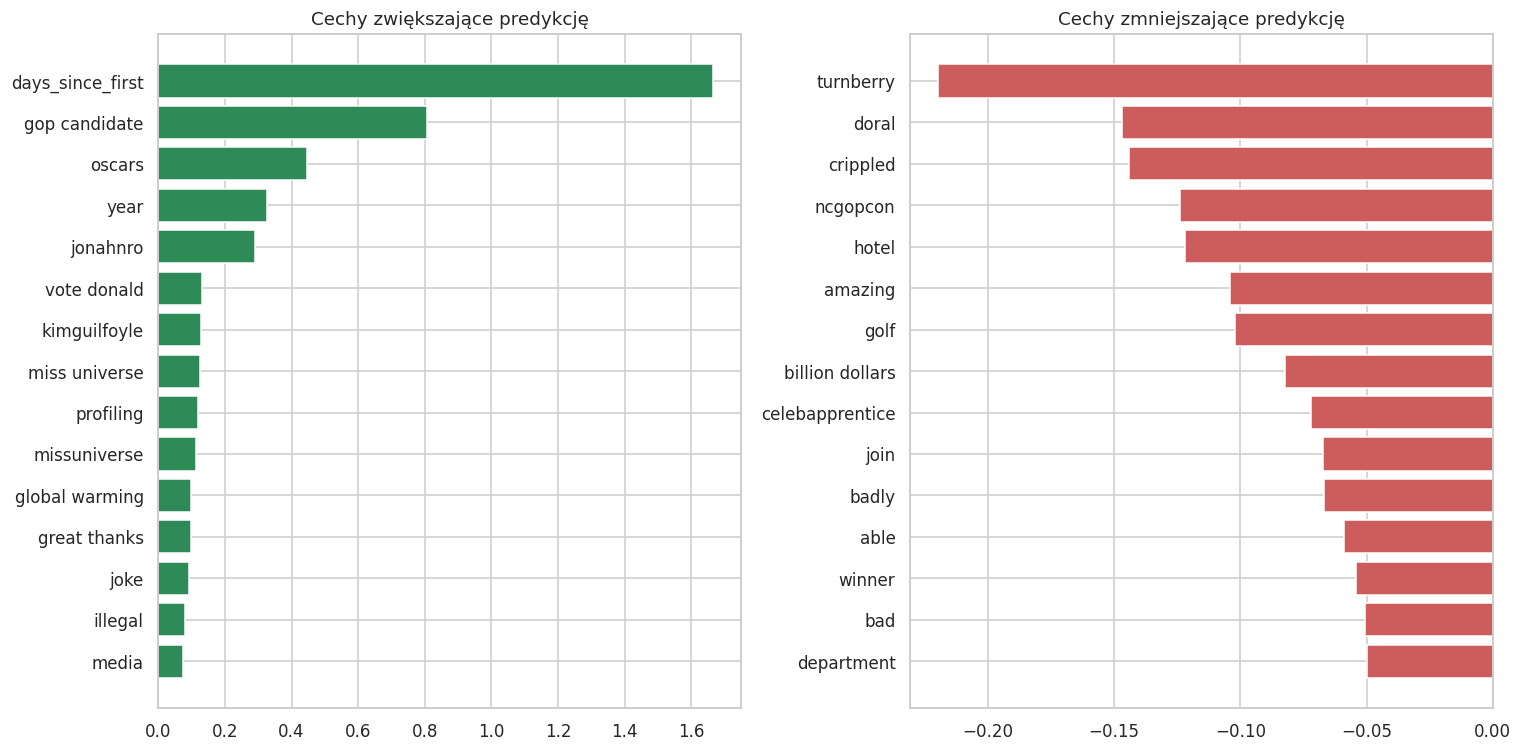

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
positive = shap_impact.sort_values("mean_shap", ascending=False).head(15).iloc[::-1]
negative = shap_impact.sort_values("mean_shap", ascending=True).head(15).iloc[::-1]
axes[0].barh(positive["feature"], positive["mean_shap"], color="seagreen")
axes[0].set_title("Cechy zwiększające predykcję")
axes[1].barh(negative["feature"], negative["mean_shap"], color="indianred")
axes[1].set_title("Cechy zmniejszające predykcję")
plt.tight_layout()
plt.show()

Jeżeli wśród najważniejszych cech pojawiają się `days_since_first` lub `year`, oznacza to, że model silnie korzysta z informacji o czasie. Wtedy interpretacja NLP powinna być ostrożna: słowa i bigramy nadal pokazują lokalne wzorce językowe, ale część jakości predykcji wynika z trendu historycznego, a nie wyłącznie z treści tweetów.

## 11.4 Waterfall plot dla poprawnie dopasowanego tweeta

Test row: 3249
Date: 2020-05-31 11:23:43
Actual retweets: 224890
Predicted retweets: 17332
Tweet: The United States of America will be designating ANTIFA as a Terrorist Organization.


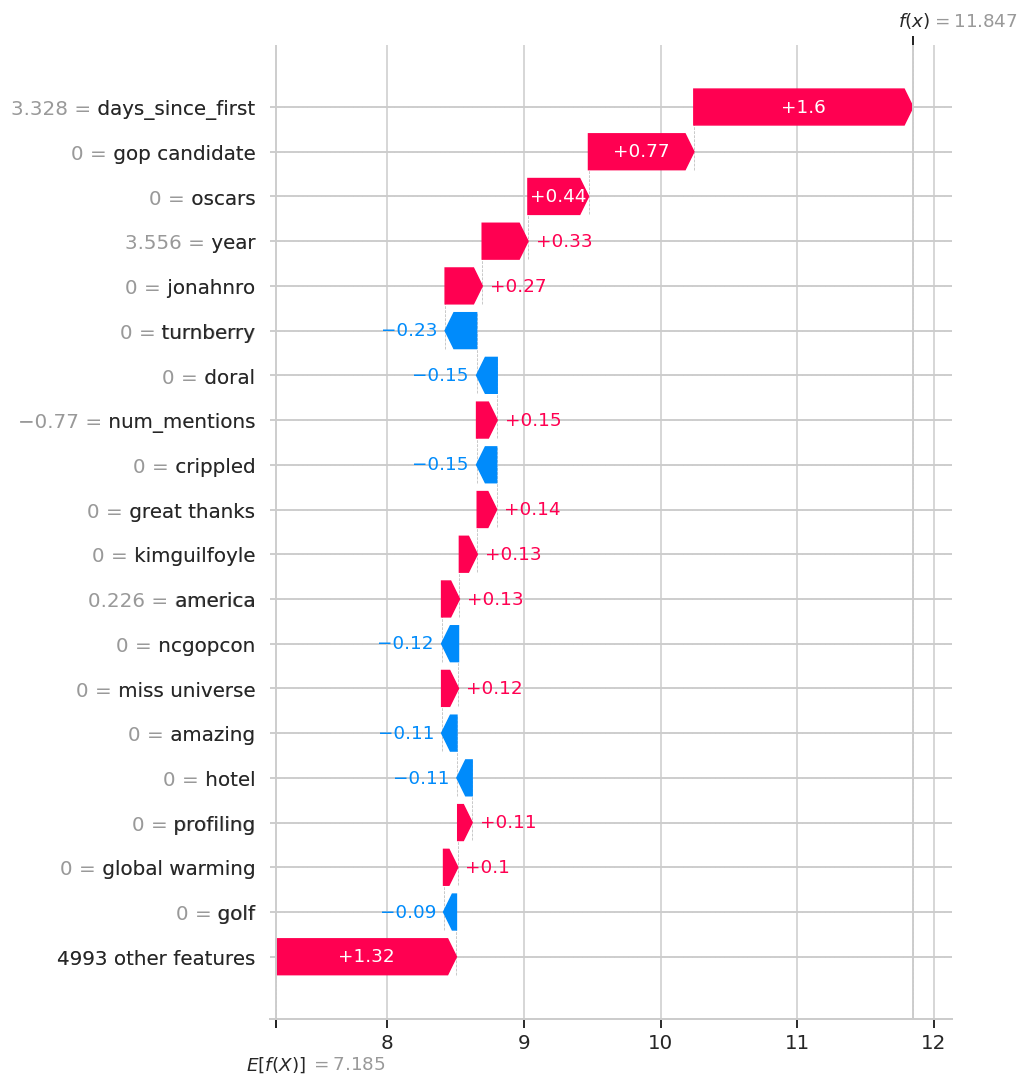

In [21]:
def show_waterfall_for_test_row(test_row_idx):
    # Display a waterfall plot and matching metadata for one X_test row.
    if test_row_idx < 0 or test_row_idx >= X_test.shape[0]:
        raise IndexError("test_row_idx is outside X_test.")

    if test_row_idx in set(shap_indices):
        shap_pos = int(np.where(shap_indices == test_row_idx)[0][0])
        values = shap_values[shap_pos]
        data = X_shap[shap_pos]
    else:
        data = X_test[test_row_idx].toarray()[0]
        values = np.asarray(explainer.shap_values(data.reshape(1, -1)))[0]

    meta = df_test_meta.iloc[test_row_idx]
    pred_log = float(final_model.predict(X_test[test_row_idx])[0])
    print(f"Test row: {test_row_idx}")
    print(f"Date: {meta['date']}")
    print(f"Actual retweets: {meta['retweets']}")
    print(f"Predicted retweets: {np.expm1(max(pred_log, 0)):.0f}")
    print(f"Tweet: {meta['content']}")
    explanation = shap.Explanation(values=values, base_values=base_value, data=data, feature_names=feature_names)
    shap.waterfall_plot(explanation, max_display=20)
    plt.show()


example_test_idx = int(df_test_meta["retweets"].astype(float).idxmax())
show_waterfall_for_test_row(example_test_idx)

## 11.5 Ridge coefficients vs SHAP

In [22]:
ridge_path = PROCESSED_DIR / "ridge_model.joblib"
if ridge_path.exists() and len(feature_names) > 0:
    ridge_model = joblib.load(ridge_path)
    ridge_coef = pd.DataFrame({"feature": feature_names, "ridge_coef": ridge_model.coef_})
    comparison = shap_impact.merge(ridge_coef, on="feature", how="inner")
    corr = comparison["ridge_coef"].corr(comparison["mean_shap"])
    print(f"Pearson correlation between Ridge coefficients and mean SHAP: {corr:.3f}")
    display(comparison.sort_values("mean_abs_shap", ascending=False).head(20))
else:
    print("Ridge model or feature names are not available for coefficient comparison.")

Pearson correlation between Ridge coefficients and mean SHAP: 0.079


,feature,mean_shap,mean_abs_shap,ridge_coef
0,days_since_first,1.666027,1.666027,2.226261
1,gop candidate,0.805674,0.805674,0.368504
2,oscars,0.445917,0.445917,1.134614
4,year,0.325001,0.325001,-0.602623
3,year,0.325001,0.325001,0.307571
5,jonahnro,0.291464,0.291464,-1.548602
6,turnberry,-0.219883,0.219883,-1.699608
7,doral,-0.146834,0.146834,-1.691612
8,crippled,-0.144149,0.144149,0.210645
9,vote donald,0.131461,0.131461,1.720382


Korelację między współczynnikami Ridge i średnimi wartościami SHAP należy opisywać zgodnie z jej wartością. Wartość około `0.17` oznacza słabą dodatnią korelację, a nie wysoką zgodność. Ridge jest modelem liniowym, natomiast XGBoost i wartości SHAP mogą odzwierciedlać nieliniowości oraz interakcje między cechami.

# 12. Discussion and conclusions

Projekt buduje kompletny pipeline predykcji zainteresowania tweetami z użyciem metod NLP: dane są ładowane z jednego źródła, dzielone chronologicznie, a TF-IDF oraz skalowanie są dopasowywane wyłącznie na treningu. Dzięki temu ewaluacja lepiej odpowiada realistycznemu zadaniu przewidywania przyszłych tweetów.

Wyniki nie powinny być interpretowane jako dowód, że retweety da się łatwo i skutecznie przewidywać. Liczba retweetów zależy od viralowych outlierów, zmieniającej się liczby odbiorców konta, kontekstu politycznego i przesunięcia czasowego. Ujemne `R2`, jeżeli występuje w tabelach wyników, oznacza wynik gorszy od prostego modelu średniej na danym podziale.

Reprezentacja TF-IDF pozwala analizować wpływ słów i bigramów, ale warianty z metadanymi czasowymi mogą korzystać przede wszystkim z trendu historycznego. SHAP pomaga oddzielić te efekty: jeżeli dominują cechy takie jak `days_since_first` lub `year`, model opiera się mocno na czasie, a nie tylko na semantyce treści.

Ograniczenie danych do okresu od 2015 roku może zmniejszyć przesunięcie rozkładu względem bardzo starych tweetów. Nie rozwiązuje to jednak całego problemu, ponieważ zainteresowanie tweetami nadal zależy od wydarzeń zewnętrznych i dynamiki platformy.

Możliwe dalsze usprawnienia obejmują bogatsze reprezentacje tekstu, np. BERT lub sentence transformers, dodanie liczby obserwujących w momencie publikacji, osobne zadanie klasyfikacji tweetów wysoko-retweetowanych, odporniejsze funkcje straty oraz walidację kroczącą w czasie.